In [1]:
%matplotlib ipympl

import mujoco

import time
import itertools
import numpy as np
import mediapy as media
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from pathlib import Path
import enum
from tqdm import tqdm

In [2]:
class Resolution(enum.Enum):
  SD = (480, 640)
  HD = (720, 1280)
  UHD = (2160, 3840)

res = Resolution.SD
h, w = res.value

In [3]:
# from robot_descriptions import spot_mj_description
model_dir = Path("mujoco_menagerie/boston_dynamics_spot/scene_arm.xml")
model_xml = model_dir / "scene_arm.xml"
# model = mujoco.MjModel.from_xml_path(spot_mj_description.MJCF_PATH)
model = mujoco.MjModel.from_xml_path(str(model_dir))
data = mujoco.MjData(model)

""

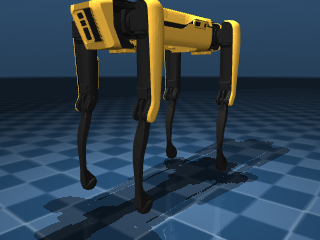

In [4]:
with mujoco.Renderer(model) as renderer:
  mujoco.mj_forward(model, data)
  renderer.update_scene(data)

  media.show_image(renderer.render())

""

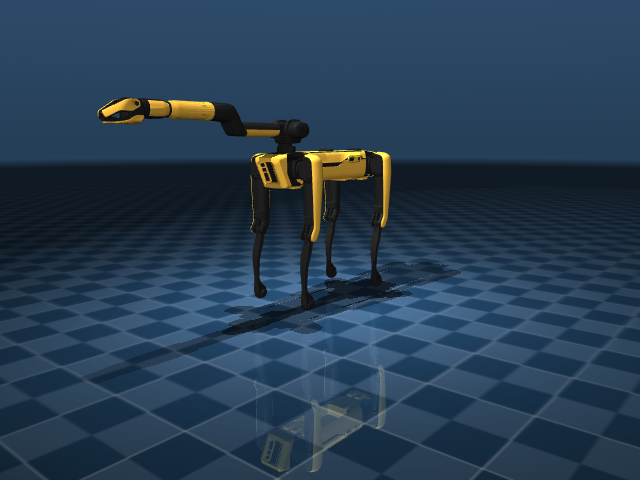

In [5]:
# data.joint('arm_sh0').qpos = np.pi

model.vis.global_.offheight = h
model.vis.global_.offwidth = w
camera = mujoco.MjvCamera()
mujoco.mjv_defaultFreeCamera(model, camera)
camera.distance = 3

renderer = mujoco.Renderer(model, height=h, width=w)

mujoco.mj_forward(model, data)
renderer.update_scene(data, camera)
media.show_image(renderer.render())

In [6]:
# print(data.joint('arm_sh0'))

joints = ["arm_sh0", "arm_sh1", "arm_el0", "arm_el1", "arm_wr0", "arm_wr1"]
bodies = ["arm_link_sh0", "arm_link_sh1", "arm_link_el0", "arm_link_el1", "arm_link_wr0", "arm_link_wr1"]
for body in bodies:
    print(np.round(data.body(body).xpos, 3))
print('\n')
for joint in joints:
    print(np.round(data.joint(joint).qpos, 3))

[0.292 0.    0.938]
[0.292 0.    0.938]
[0.631 0.    0.938]
[1.034 0.    1.013]
[1.034 0.    1.013]
[1.034 0.    1.013]


[0.]
[0.]
[0.]
[0.]
[0.]
[0.]


In [7]:
from dataclasses import dataclass
import numpy as np
import mediapy as media
from pathlib import Path
import enum
from tqdm import tqdm
import mujoco

from numpy import pi

def quartic(t: float) -> float:
  return 0 if abs(t) > 1 else (1 - t**2) ** 2


def blend_coef(t: float, duration: float, std: float) -> float:
  normalised_time = 2 * t / duration - 1
  return quartic(normalised_time / std)


In [8]:
res = Resolution.SD
fps = 30
duration = 5.0
ctrl_rate = 2
ctrl_std = 0.05

# Rendering options for visual and collision geoms.
vis = mujoco.MjvOption()
vis.geomgroup[2] = True
vis.geomgroup[3] = False
coll = mujoco.MjvOption()
coll.geomgroup[2] = False
coll.geomgroup[3] = True
coll.flags[mujoco.mjtVisFlag.mjVIS_CONVEXHULL] = True

# Sample actuator noise and smooth it.
nsteps = int(np.ceil(duration / model.opt.timestep))
perturb = np.random.randn(nsteps, model.nu)
width = int(nsteps * ctrl_rate / duration)
kernel = np.exp(-0.5 * np.linspace(-3, 3, width) ** 2)
kernel /= np.linalg.norm(kernel)
for i in range(model.nu):
  perturb[:, i] = np.convolve(perturb[:, i], kernel, mode="same")

# Set the desired control point.
if model.nkey > 0:
  mujoco.mj_resetDataKeyframe(model, data, 0)
  ctrl0 = data.ctrl.copy()
else:
  mujoco.mj_resetData(model, data)
  ctrl0 = np.mean(model.actuator_ctrlrange, axis=1)

camera.distance = 2

data.joint("arm_sh0").qpos = pi/4
frames = []
for i in tqdm(range(nsteps)):
  # data.ctrl[0:12] = ctrl0[0:12] + ctrl_std * perturb[i, 0:12]
  mujoco.mj_step(model, data)
  if len(frames) < data.time * fps:
    renderer.update_scene(data, camera)
    frame = renderer.render().copy().astype(np.uint8)
    frames.append(frame)
media.show_video(frames, fps=fps, loop=False)

100%|██████████| 2500/2500 [00:01<00:00, 1329.61it/s]


This browser does not support the video tag.


Важно учитывать конфигурацию робота, в которой он находится в момент расчета координат (по результатам симуляции выше) или _(как-то)_ "сбросить" положение звеньев.

In [9]:
joints = ["arm_sh0", "arm_sh1", "arm_el0", "arm_el1", "arm_wr0", "arm_wr1"]
bodies = ["arm_link_sh0", "arm_link_sh1", "arm_link_el0", "arm_link_el1", "arm_link_wr0", "arm_link_wr1"]
for body in bodies:
    print(np.round(data.body(body).xpos, 3))
print('\n')
for joint in joints:
    print(np.round(data.joint(joint).qpos, 3))

[0.278 0.004 0.618]
[0.278 0.004 0.618]
[-0.06   0.001  0.62 ]
[0.338 0.005 0.716]
[0.338 0.005 0.716]
[0.338 0.005 0.716]


[0.]
[-3.14]
[3.083]
[0.]
[0.003]
[-0.]


Да, длины звеньев в целом соответствуют значениям, приведенным производителем.

In [10]:
def calc_vel(x, y, z):
    if len(z) < 2:
        vel = np.array([0, 0, 0])
    else:
        vel = np.array([x[-1] - x[-2],
                        y[-1] - y[-2],
                        z[-1] - z[-2]])
    return vel

class DH_params():
    def __init__(self):
        self.a = np.zeros(6)
        self.d = np.zeros(6)
        self.alpha = np.zeros(6)
        self.theta = np.zeros(6)
    
    def add_theta(self, q):
        self.theta += q

l1 = 0.12
l2 = 0.339
l3 = 0.403
h3 = 0.075
l5 = 0.117

DH = DH_params()
DH.a = np.array([       0,      l2,     h3,     0,      0,      0])
DH.d = np.array([       l1,     0,      0,      l3,     0,      l5])
DH.alpha = np.array([   pi/2,   pi,     pi/2,   pi/2,   pi/2,   pi/2])
DH.theta = np.array([   0.0,    0.0,    0.0,    0.0,    0.0,0.0])

DH.add_theta(np.array([0, -pi, pi, 0, 0, 0]))

100%|██████████| 2500/2500 [00:02<00:00, 1219.18it/s]


This browser does not support the video tag.


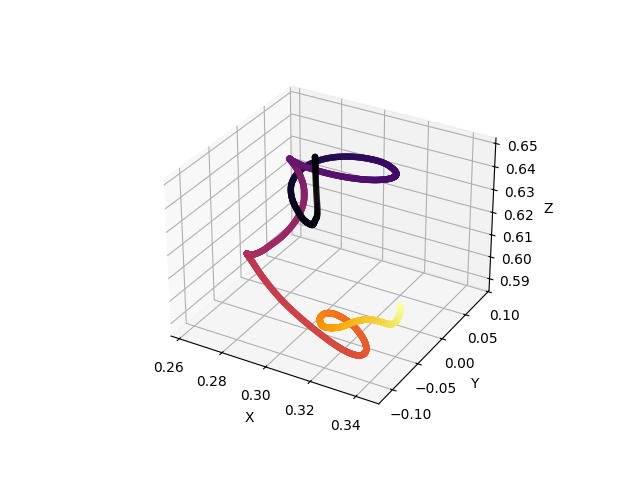

In [29]:
duration = 5.0
ctrl_rate = 2
ctrl_std = 0.075

np.random.seed(10)

# Sample actuator noise and smooth it.
nsteps = int(np.ceil(duration / model.opt.timestep))
perturb = np.random.randn(nsteps, model.nu)
width = int(nsteps * ctrl_rate / duration)
kernel = np.exp(-0.5 * np.linspace(-3, 3, width) ** 2)
kernel /= np.linalg.norm(kernel)
for i in range(model.nu):
  perturb[:, i] = np.convolve(perturb[:, i], kernel, mode="same")

# Set the desired control point.
if model.nkey > 0:
  mujoco.mj_resetDataKeyframe(model, data, 0)
  ctrl0 = data.ctrl.copy()
else:
  mujoco.mj_resetData(model, data)
  ctrl0 = np.mean(model.actuator_ctrlrange, axis=1)

t = np.array([])
x, y, z = np.array([]), np.array([]), np.array([])
xvel, yvel, zvel = np.array([]), np.array([]), np.array([])

frames = []

for i in tqdm(range(nsteps)):
  data.ctrl[0:12] = ctrl0[0:12] + ctrl_std * perturb[i, 0:12]
  if data.body("arm_link_sh0").xpos[0] != 0:
    t = np.append(t, i)
    x = np.append(x, data.body("arm_link_sh0").xpos[0])
    y = np.append(y, data.body("arm_link_sh0").xpos[1])
    z = np.append(z, data.body("arm_link_sh0").xpos[2])
    vel = calc_vel(x, y, z)
    vel *= 10^5
    xvel =np.append(xvel, vel[0])
    yvel =np.append(yvel, vel[1])
    zvel =np.append(zvel, vel[2])
  # xvel = np.append(xvel, data.body("arm_link_sh0").cvel[0])
  # yvel = np.append(yvel, data.body("arm_link_sh0").cvel[1])
  # zvel = np.append(zvel, data.body("arm_link_sh0").cvel[2])
  
  mujoco.mj_step(model, data)
  if len(frames) < data.time * fps:
    renderer.update_scene(data, camera)
    frame = renderer.render().copy().astype(np.uint8)
    frames.append(frame)

media.show_video(frames, fps=fps, loop=False)


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, c=np.linspace(0, 1, len(x)), cmap='inferno', linewidth=0.2)
for i in range(0, len(t), 100):
  ax.quiver(x[i], y[i], z[i], xvel[i], yvel[i], zvel[i], color='r', linewidth=1)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()
# 
#     Как показала практика - скорость в модели не соответствует реальному
#   направлению двжиения базы. Лучше использовать изменения координат с малым шагом.
# 